# Pipeline Dự đoán Đua ngựa — Refactored

**Thay đổi so với bản gốc:**
- `ScalerRegistry`: wrapper để đăng ký/thử nghiệm các hàm normalization tùy ý
- `_fit_scale_col()`: helper dùng chung, loại bỏ đoạn code lặp giữa các strategy
- `_fill_columns()`: helper gom các lệnh `fillna` lặp trong `process()`
- Config `numerical_configs` giờ chỉ cần ghi tên strategy → tự map sang hàm qua registry

In [1]:
!pip install mlflow


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
import mlflow

mlflow.set_experiment("my-notebook-exp")

with mlflow.start_run():
    mlflow.log_param("lr", 0.01)
    mlflow.log_param("epochs", 10)

    accuracy = 0.92
    mlflow.log_metric("accuracy", accuracy)

In [51]:
import os

print("--- DANH SÁCH TOÀN BỘ FILE ĐANG CÓ TRÊN KAGGLE ---")
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        # Lọc ra để chỉ in những file có đuôi .csv cho dễ nhìn
        if filename.endswith('.csv'):
            print(os.path.join(dirname, filename))

--- DANH SÁCH TOÀN BỘ FILE ĐANG CÓ TRÊN KAGGLE ---


# Load data

In [52]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import re

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
BLUE, ORANGE, GREEN, RED, GREY = '#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8c8c8c'

# ── Paths: Local ───────────────────────────────────────────────────
# Đặt trực tiếp đường dẫn tới thư mục chứa dữ liệu trên máy tính của bạn
DATA = Path('D:/Horse/datasets/zoupet/horses-races-results-20252026')

races        = pd.read_csv(DATA / 'races.csv', parse_dates=['race_datetime'])
runners      = pd.read_csv(DATA / 'runners.csv')
odds         = pd.read_csv(DATA / 'odds.csv')
race_results = pd.read_csv(DATA / 'race_results.csv', parse_dates=['race_datetime'])

print('Loaded:')
print(f'  races.csv        {len(races):>7,} rows')
print(f'  runners.csv      {len(runners):>7,} rows')
print(f'  odds.csv         {len(odds):>7,} rows')
print(f'  race_results.csv {len(race_results):>7,} rows')
print(f'\nDate range: {races.date.min()} -> {races.date.max()}')

Loaded:
  races.csv          4,108 rows
  runners.csv       50,818 rows
  odds.csv          99,348 rows
  race_results.csv  38,314 rows

Date range: 20250909 -> 20260311


# Cấu hình pipeline

In [53]:
CONFIG = {
    'target_col': 'target_top_3',
    'test_size': 0.2,

    'te_k': 5,
    'te_f': 1,

    'categorical_cols': ['jockey_name', 'horse_name', 'trainer_name'],

    # Tên strategy phải khớp với key đã đăng ký trong ScalerRegistry
    # Muốn thử strategy mới: thêm key mới ở đây + đăng ký hàm trong registry
    'numerical_configs': {
        'minmax':   ['field_size', 'horse_number'],
        'standard': ['distance_metres', 'handicap_distance'],
        'robust': ['final_odds', 'avg_rank', 'last_rank'],
        'none':     [],
    },

    'cols_to_drop': [
        'weight_kg', 'track_condition', 'odds_type', 'decimal_odds',
        'draw_position', 'date_x', 'date_y', 'hippodrome_x', 'hippodrome_y',
        'is_recent', 'htj_count', 'snapshot_time', 'race_datetime', 'km_time',
        'date_race', 'hippodrome_race', 'distance_metres_race', 'morning_odds',
        'implied_prob', 'course_number', 'date', 'reunion_number', 'scratch',
        'is_trot', 'runner_id', 'race_id', 'odds_id', 'finish_position', 'discipline'
    ]
}

# Chọn các thuật toán chuẩn hoá feature

- StandardScaler: Dùng khi dữ liệu có phân phối chuẩn.
- MinMaxScaler: "Đưa về khoảng [0,1], nhạy cảm với Outliers."
- RobustScaler:​ Khuyên dùng nếu dữ liệu có nhiều giá trị ngoại lai.
- Log Transform: "Xử lý dữ liệu bị lệch (như Tiền thưởng, Odds)."

In [54]:
# ============================================================
#  SCALER REGISTRY — wrapper cho normalization
# ============================================================
# Mỗi strategy là một dict với 2 hàm:
#   fit(series)      -> dict các tham số (fit trên train)
#   transform(series, params) -> series đã scale
#
# Để thêm strategy mới: gọi ScalerRegistry.register(name, fit_fn, transform_fn)
# hoặc dùng decorator @ScalerRegistry.register_decorator(name)
# ============================================================

class ScalerRegistry:
    _registry: dict = {}

    @classmethod
    def register(cls, name: str, fit_fn, transform_fn):
        """Đăng ký một strategy mới theo tên."""
        cls._registry[name] = {'fit': fit_fn, 'transform': transform_fn}

    @classmethod
    def get(cls, name: str) -> dict:
        if name not in cls._registry:
            raise ValueError(f"Strategy '{name}' chưa được đăng ký. Có sẵn: {list(cls._registry.keys())}")
        return cls._registry[name]

    @classmethod
    def list_strategies(cls):
        return list(cls._registry.keys())


# ── Đăng ký các strategy có sẵn ─────────────────────────────

# 1. Min-Max Scaling → [0, 1]
ScalerRegistry.register(
    'minmax',
    fit_fn=lambda s: {'min': s.min(), 'max': s.max()},
    transform_fn=lambda s, p: (s - p['min']) / (max(p['max'] - p['min'], 1e-9))
)

# 2. Standard Scaling (Z-Score) → mean=0, std=1
ScalerRegistry.register(
    'standard',
    fit_fn=lambda s: {'mean': s.mean(), 'std': s.std()},
    transform_fn=lambda s, p: (s - p['mean']) / (max(p['std'], 1e-9))
)

# 3. Robust Scaling → dùng median + IQR, chống outlier tốt hơn standard
ScalerRegistry.register(
    'robust',
    fit_fn=lambda s: {'median': s.median(), 'iqr': s.quantile(0.75) - s.quantile(0.25)},
    transform_fn=lambda s, p: (s - p['median']) / (max(p['iqr'], 1e-9))
)

# 4. Log Scaling → log1p để tránh log(0), tốt cho phân phối lệch phải
ScalerRegistry.register(
    'log',
    fit_fn=lambda s: {},  # Không cần tham số
    transform_fn=lambda s, p: np.log1p(s.clip(lower=0))
)

# 5. None — giữ nguyên (bỏ qua, không scale)
ScalerRegistry.register(
    'none',
    fit_fn=lambda s: {},
    transform_fn=lambda s, p: s
)


def quantile_fit(s):
    return {'q10': s.quantile(0.1), 'q90': s.quantile(0.9)}
def quantile_transform(s, p):
    return (s - p['q10']) / max(p['q90'] - p['q10'], 1e-9)
ScalerRegistry.register('quantile', quantile_fit, quantile_transform)

print(f"Các strategy có sẵn: {ScalerRegistry.list_strategies()}")

Các strategy có sẵn: ['minmax', 'standard', 'robust', 'log', 'none', 'quantile']


# Lớp tiền xử lý dữ liệu
- Điền data khuyết
- Chuyển cột musique(chuỗi gồm kết quả thi đấu gần nhất của ngựa) thành tham số dùng được
- Xử lý các cột không cần thiết

In [55]:
import pandas as pd
import numpy as np
import re

class DataPreprocessor:
    def __init__(self, config):
        self.config = config

    # ── Helper: fill một nhóm cột theo strategy ─────────────
    def _fill_columns(self, df, fill_specs: list):
        """
        fill_specs: list of (col, value_or_callable)
        Nếu value là callable, gọi nó với df[col] (vd: lambda s: s.median())
        """
        for col, fill_val in fill_specs:
            if col not in df.columns:
                continue
            val = fill_val(df[col]) if callable(fill_val) else fill_val
            df[col] = df[col].fillna(val)
        return df

    def extract_musique(self, musique_str):
        if pd.isna(musique_str) or str(musique_str).strip() in ["", "None", "nan"]:
            return pd.Series([np.nan, np.nan, 0.0, 0.0])

        s = str(musique_str).lower()
        s = re.sub(r'\(.*?\)', '', s)
        raw_results = re.findall(r'(\d|[dat])(?=[p|a|m|s|h|c]|$)', s)

        ranks = []
        for res in raw_results:
            if res.isdigit():
                val = int(res)
                ranks.append(val if val > 0 else 10)
            elif res in ['d', 'a', 't']:
                ranks.append(12)

        if not ranks:
            return pd.Series([np.nan, np.nan, 0.0, 0.0])

        return pd.Series([
            float(ranks[0]),
            float(np.mean(ranks[:5])),
            float(sum(1 for r in ranks if r == 1) / len(ranks)),
            float(sum(1 for r in ranks if r <= 3) / len(ranks))
        ])

    def process(self, runners, races, odds, race_results):
        print("1. Đang merge dữ liệu...")
        df = pd.merge(runners, races, on='race_id', how='left', suffixes=('', '_race'))
        df = pd.merge(df, odds, on=['race_id', 'runner_id'], how='left')
        df = pd.merge(df, race_results, on=['race_id', 'runner_id'], how='left', suffixes=('', '_res'))

        print("2. Tạo Target và lọc dữ liệu...")
        if 'finish_position' in df.columns:
            df['target_top_3'] = df['finish_position'].apply(lambda x: 1 if 1 <= x <= 3 else 0)

        df = df[df['scratch'] == False].copy()
        df = df[df['finish_position'].notna()].copy()

        print("3. Điền khuyết & Trích xuất đặc trưng (Musique)...")
        df['date']             = df['date_race']
        df['hippodrome']       = df['hippodrome_race']
        df['discipline_binary'] = (df['discipline'] == 'TROT_MONTE').astype(int)

        # ── Gom fillna vào một chỗ, dễ thêm/sửa ────────────
        df = self._fill_columns(df, [
            ('finish_position_res', 99),
            ('km_time_res',         lambda s: s.median()),
            ('implied_prob_norm',   lambda s: s.median()),
        ])

        df[['last_rank', 'avg_rank', 'win_rate', 'top_3_rate']] = df['musique'].apply(self.extract_musique)

        print("4. Xóa cột thừa...")
        res_cols  = [col for col in df.columns if col.endswith('_res')]
        drop_cols = list(set(self.config['cols_to_drop'] + res_cols))
        df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

        if 'race_datetime' in df.columns:
            df = df.sort_values('race_datetime')

        return df

In [56]:
class FeatureEngineer:
    def __init__(self, config):
        self.config   = config
        self.te_maps  = {}
        self.scalers  = {}  # Lưu {col: {'strategy': ..., 'params': ...}}

    # ── Helper: fit một cột trên train, transform cả hai tập ──
    def _fit_scale_col(self, col, strategy_name, train_s, test_s):
        """
        - Fit strategy trên train_s
        - Transform cả train_s và test_s bằng params đã fit
        - Lưu params vào self.scalers[col]
        Returns: (train_scaled, test_scaled)
        """
        strategy = ScalerRegistry.get(strategy_name)
        params   = strategy['fit'](train_s)
        self.scalers[col] = {'strategy': strategy_name, 'params': params}

        train_scaled = strategy['transform'](train_s, params)
        test_scaled  = strategy['transform'](test_s,  params)  # dùng params của TRAIN
        return train_scaled, test_scaled

    def fit_transform(self, df_train, df_test):
        train = df_train.copy()
        test  = df_test.copy()
        target      = self.config['target_col']
        global_mean = train[target].mean()

        # ── 1. Sigmoid Target Encoding ───────────────────────
        print("1. Đang chạy Sigmoid Target Encoding...")
        for col in self.config['categorical_cols']:
            if col not in train.columns:
                continue

            train[col] = train[col].fillna('Unknown')
            test[col]  = test[col].fillna('Unknown')

            agg    = train.groupby(col)[target].agg(['count', 'mean'])
            counts = agg['count']
            weights = 1 / (1 + np.exp(-(counts - self.config['te_k']) / self.config['te_f']))
            estimated_prob = weights * agg['mean'] + (1 - weights) * global_mean

            self.te_maps[col] = estimated_prob.to_dict()
            new_col = f'{col}_prob'

            train[new_col] = train[col].map(self.te_maps[col]).fillna(global_mean)
            test[new_col]  = test[col].map(self.te_maps[col]).fillna(global_mean)

            train = train.drop(columns=[col])
            test  = test.drop(columns=[col])

        # ── 2. Multi-Strategy Normalization (qua registry) ───
        print("2. Đang chạy Multi-Strategy Normalization...")
        num_configs = self.config['numerical_configs']

        for strategy_name, cols in num_configs.items():
            if strategy_name == 'none':
                continue  # Giữ nguyên, không cần làm gì

            for col in cols:
                if col not in train.columns:
                    continue
                print(f"   [{strategy_name}] {col}")
                train[col], test[col] = self._fit_scale_col(
                    col, strategy_name, train[col], test[col]
                )

        return train, test

In [57]:
import pandas as pd
from pathlib import Path

def split_train_test_by_time(df, test_size):
    split_idx = int(len(df) * (1 - test_size))
    return df.iloc[:split_idx], df.iloc[split_idx:]

# --- BƯỚC 0: TẢI DỮ LIỆU ---
# Thiết lập đường dẫn tới thư mục local của bạn
DATA = Path('D:/Horse/datasets/zoupet/horses-races-results-20252026')

runners = pd.read_csv(DATA / 'runners.csv')
races = pd.read_csv(DATA / 'races.csv')
odds = pd.read_csv(DATA / 'odds.csv')
race_results = pd.read_csv(DATA / 'race_results.csv')

# --- CHẠY PIPELINE ---

# BƯỚC 1: Tiền xử lý
# (Lưu ý: Đảm bảo rằng class DataPreprocessor và dictionary CONFIG đã được định nghĩa ở trên)
preprocessor = DataPreprocessor(CONFIG)
df_clean = preprocessor.process(runners, races, odds, race_results)

# BƯỚC 2: Chia tập (Time-based)
df_train, df_test = split_train_test_by_time(df_clean, test_size=CONFIG['test_size'])

# BƯỚC 3: Feature Engineering
# (Lưu ý: Đảm bảo rằng class FeatureEngineer đã được định nghĩa ở trên)
# fe = FeatureEngineer(CONFIG)
# df_train_final, df_test_final = fe.fit_transform(df_train, df_test)

print("\n[Hoàn thành] Kích thước tập Train:", df_train.shape)
print("[Hoàn thành] Kích thước tập Test: ", df_test.shape)

# BƯỚC 4: Kiểm tra độ tương quan
corr_matrix = df_train.select_dtypes(include='number').corr()
print("\n--- Mức độ tương quan với Target ---")
print(corr_matrix[CONFIG['target_col']].sort_values(ascending=False))

# BƯỚC 5: Xem lại các tham số đã fit (debug/audit)
# print("\n--- Scalers đã fit ---")
# for col, info in fe.scalers.items():
#     print(f"  {col:25s} [{info['strategy']:8s}] params={info['params']}")

1. Đang merge dữ liệu...
2. Tạo Target và lọc dữ liệu...
3. Điền khuyết & Trích xuất đặc trưng (Musique)...
4. Xóa cột thừa...

[Hoàn thành] Kích thước tập Train: (61058, 21)
[Hoàn thành] Kích thước tập Test:  (15265, 21)

--- Mức độ tương quan với Target ---
target_top_3         1.000000
implied_prob_norm    0.409023
top_3_rate           0.205575
win_rate             0.193436
discipline_binary    0.032087
handicap_distance   -0.029303
distance_metres     -0.029493
horse_number        -0.029998
field_size          -0.141356
field_size_race     -0.141356
last_rank           -0.144525
avg_rank            -0.157399
odds_drift_pct      -0.228285
final_odds          -0.326906
Name: target_top_3, dtype: float64


In [58]:
df_train

,distance_metres,field_size,horse_number,horse_name,jockey_name,trainer_name,handicap_distance,deferre,musique,discipline_race,...,hippodrome,final_odds,odds_drift_pct,implied_prob_norm,target_top_3,discipline_binary,last_rank,avg_rank,win_rate,top_3_rate
0,2150,7,1,KATARI CROWN,A. VALLS,M. VICH C.,2150,True,6aDa6a5aRa7a,TROT_ATTELE,...,SON PARDO,50.0,1.0833,0.035971,0,0,6.0,7.2,0.000000,0.000000
1,2150,7,1,KATARI CROWN,A. VALLS,M. VICH C.,2150,True,6aDa6a5aRa7a,TROT_ATTELE,...,SON PARDO,50.0,1.0833,0.035971,0,0,6.0,7.2,0.000000,0.000000
2,2150,7,2,KAPITA DE MANDIA,JME. FLUXA,J. POCOVI,2150,False,3a2a4a6a0a4a,TROT_ATTELE,...,SON PARDO,10.0,0.0000,0.086329,1,0,3.0,5.0,0.000000,0.285714
3,2150,7,2,KAPITA DE MANDIA,JME. FLUXA,J. POCOVI,2150,False,3a2a4a6a0a4a,TROT_ATTELE,...,SON PARDO,10.0,0.0000,0.086329,1,0,3.0,5.0,0.000000,0.285714
4,2150,7,3,LEO BLAI,M. MESTRE,C. SUBIRATS,2150,False,1a1a0a6a6a2a,TROT_ATTELE,...,SON PARDO,6.6,0.5000,0.196202,1,0,1.0,4.8,0.285714,0.428571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80084,2100,16,13,LIBERTE HAUFOR,D. BONNE,CH. BIGEON,2100,True,(25)Da1a1a4aDa1a2a7aDa,TROT_ATTELE,...,VINCENNES,3.5,-0.2708,0.179759,1,0,12.0,6.0,0.300000,0.400000
80085,2100,16,13,LIBERTE HAUFOR,D. BONNE,CH. BIGEON,2100,True,(25)Da1a1a4aDa1a2a7aDa,TROT_ATTELE,...,VINCENNES,3.5,-0.2708,0.179759,1,0,12.0,6.0,0.300000,0.400000
80088,2100,16,15,LAURENE DE BAILLY,M. ABRIVARD,B. BOURGOIN,2100,True,6a0a(25)0a7aDmDa6a5a8a,TROT_ATTELE,...,VINCENNES,30.0,0.3636,0.039221,0,0,6.0,9.0,0.000000,0.000000
80089,2100,16,15,LAURENE DE BAILLY,M. ABRIVARD,B. BOURGOIN,2100,True,6a0a(25)0a7aDmDa6a5a8a,TROT_ATTELE,...,VINCENNES,30.0,0.3636,0.039221,0,0,6.0,9.0,0.000000,0.000000


Đang vẽ Ma trận tương quan (Correlation Heatmap)...


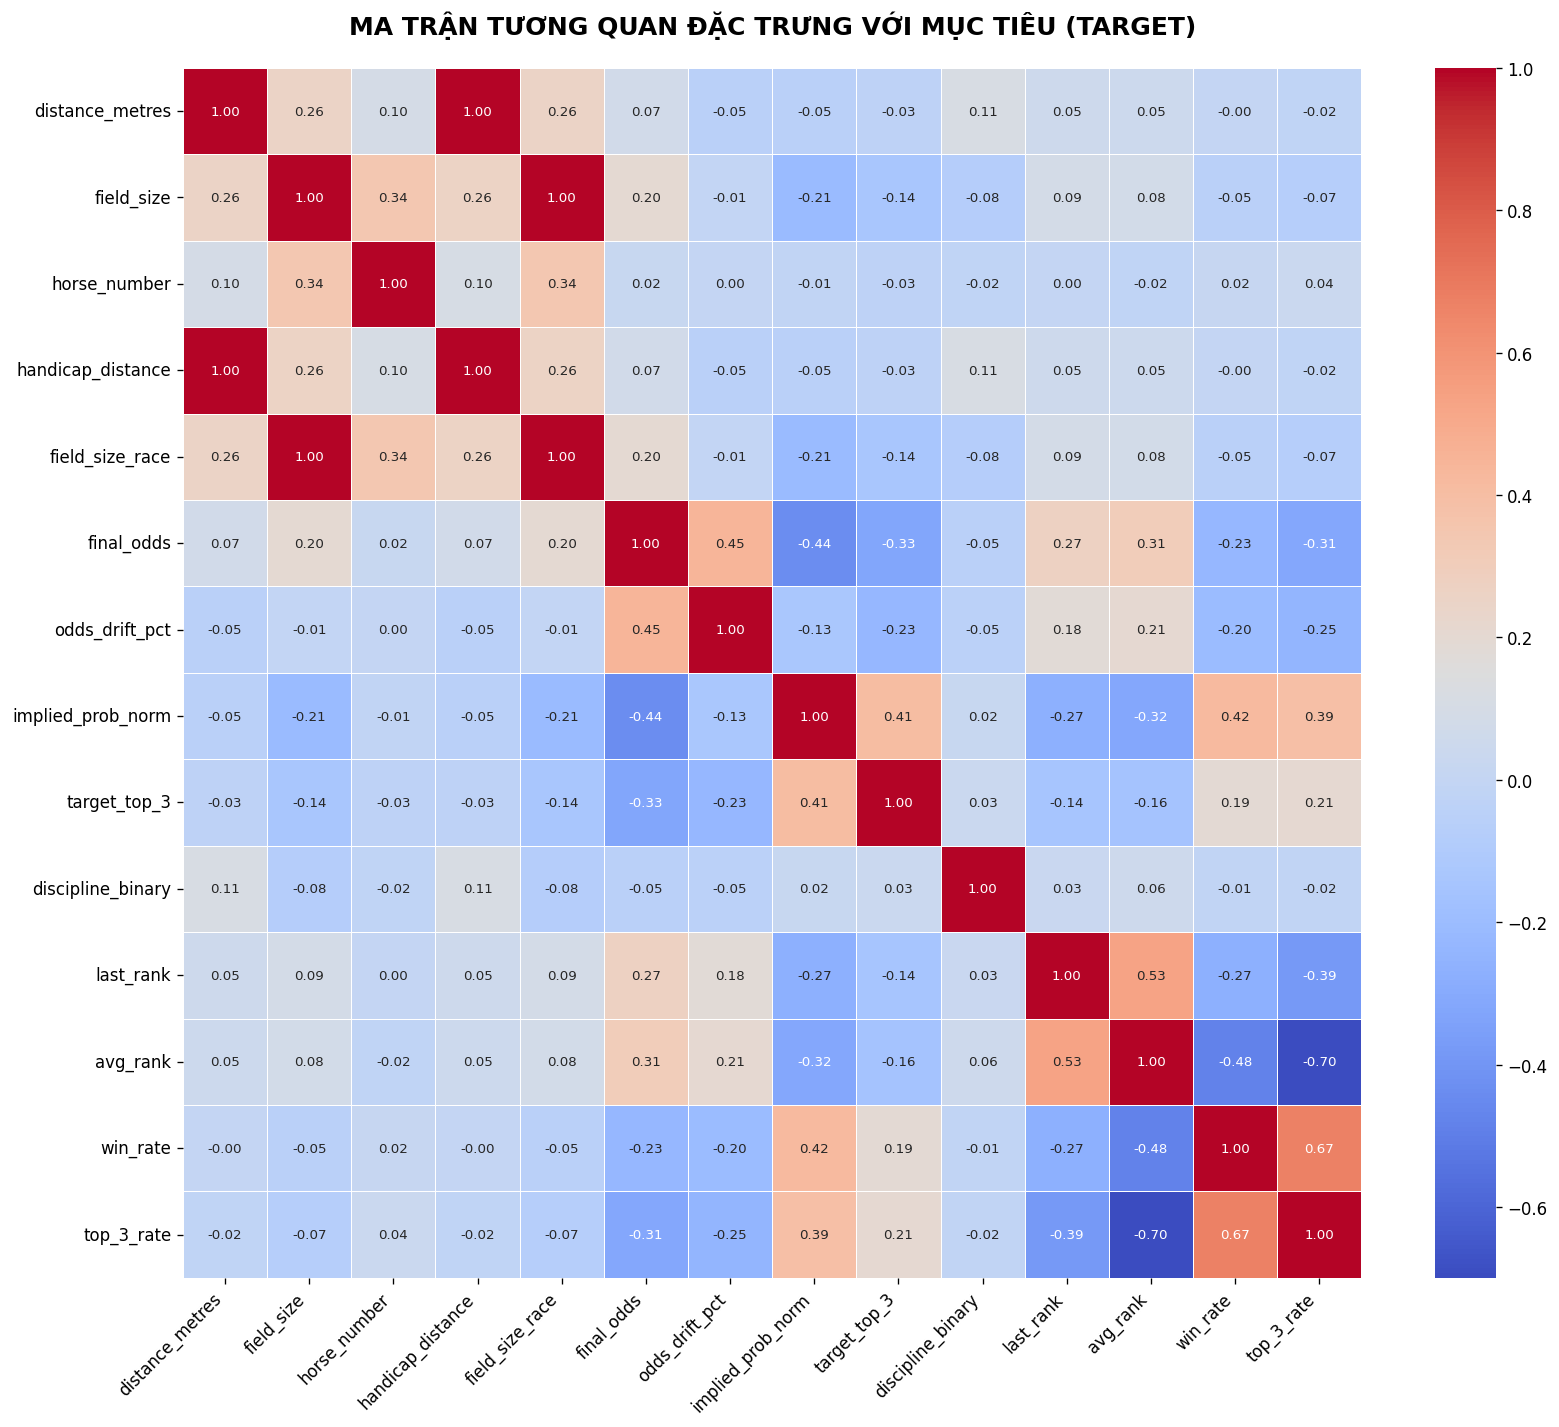

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Đang vẽ Ma trận tương quan (Correlation Heatmap)...")

# Chỉ chọn các cột số để tính tương quan
numeric_cols = df_train.select_dtypes(include=['number']).columns
corr_matrix = df_train[numeric_cols].corr()

# Khởi tạo khung hình lớn cho dễ nhìn
plt.figure(figsize=(14, 12), dpi=120)

# Vẽ Heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,              # Hiện con số
    fmt=".2f",               # Lấy 2 số thập phân
    cmap='coolwarm',         # Đỏ: Tương quan dương | Xanh: Tương quan âm
    linewidths=0.5, 
    annot_kws={"size": 8}
)

plt.title('MA TRẬN TƯƠNG QUAN ĐẶC TRƯNG VỚI MỤC TIÊU (TARGET)', fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('heatmap_correlation.png')
plt.show()

Đang phân tích hình dáng phân phối dữ liệu gốc trên tập Train...


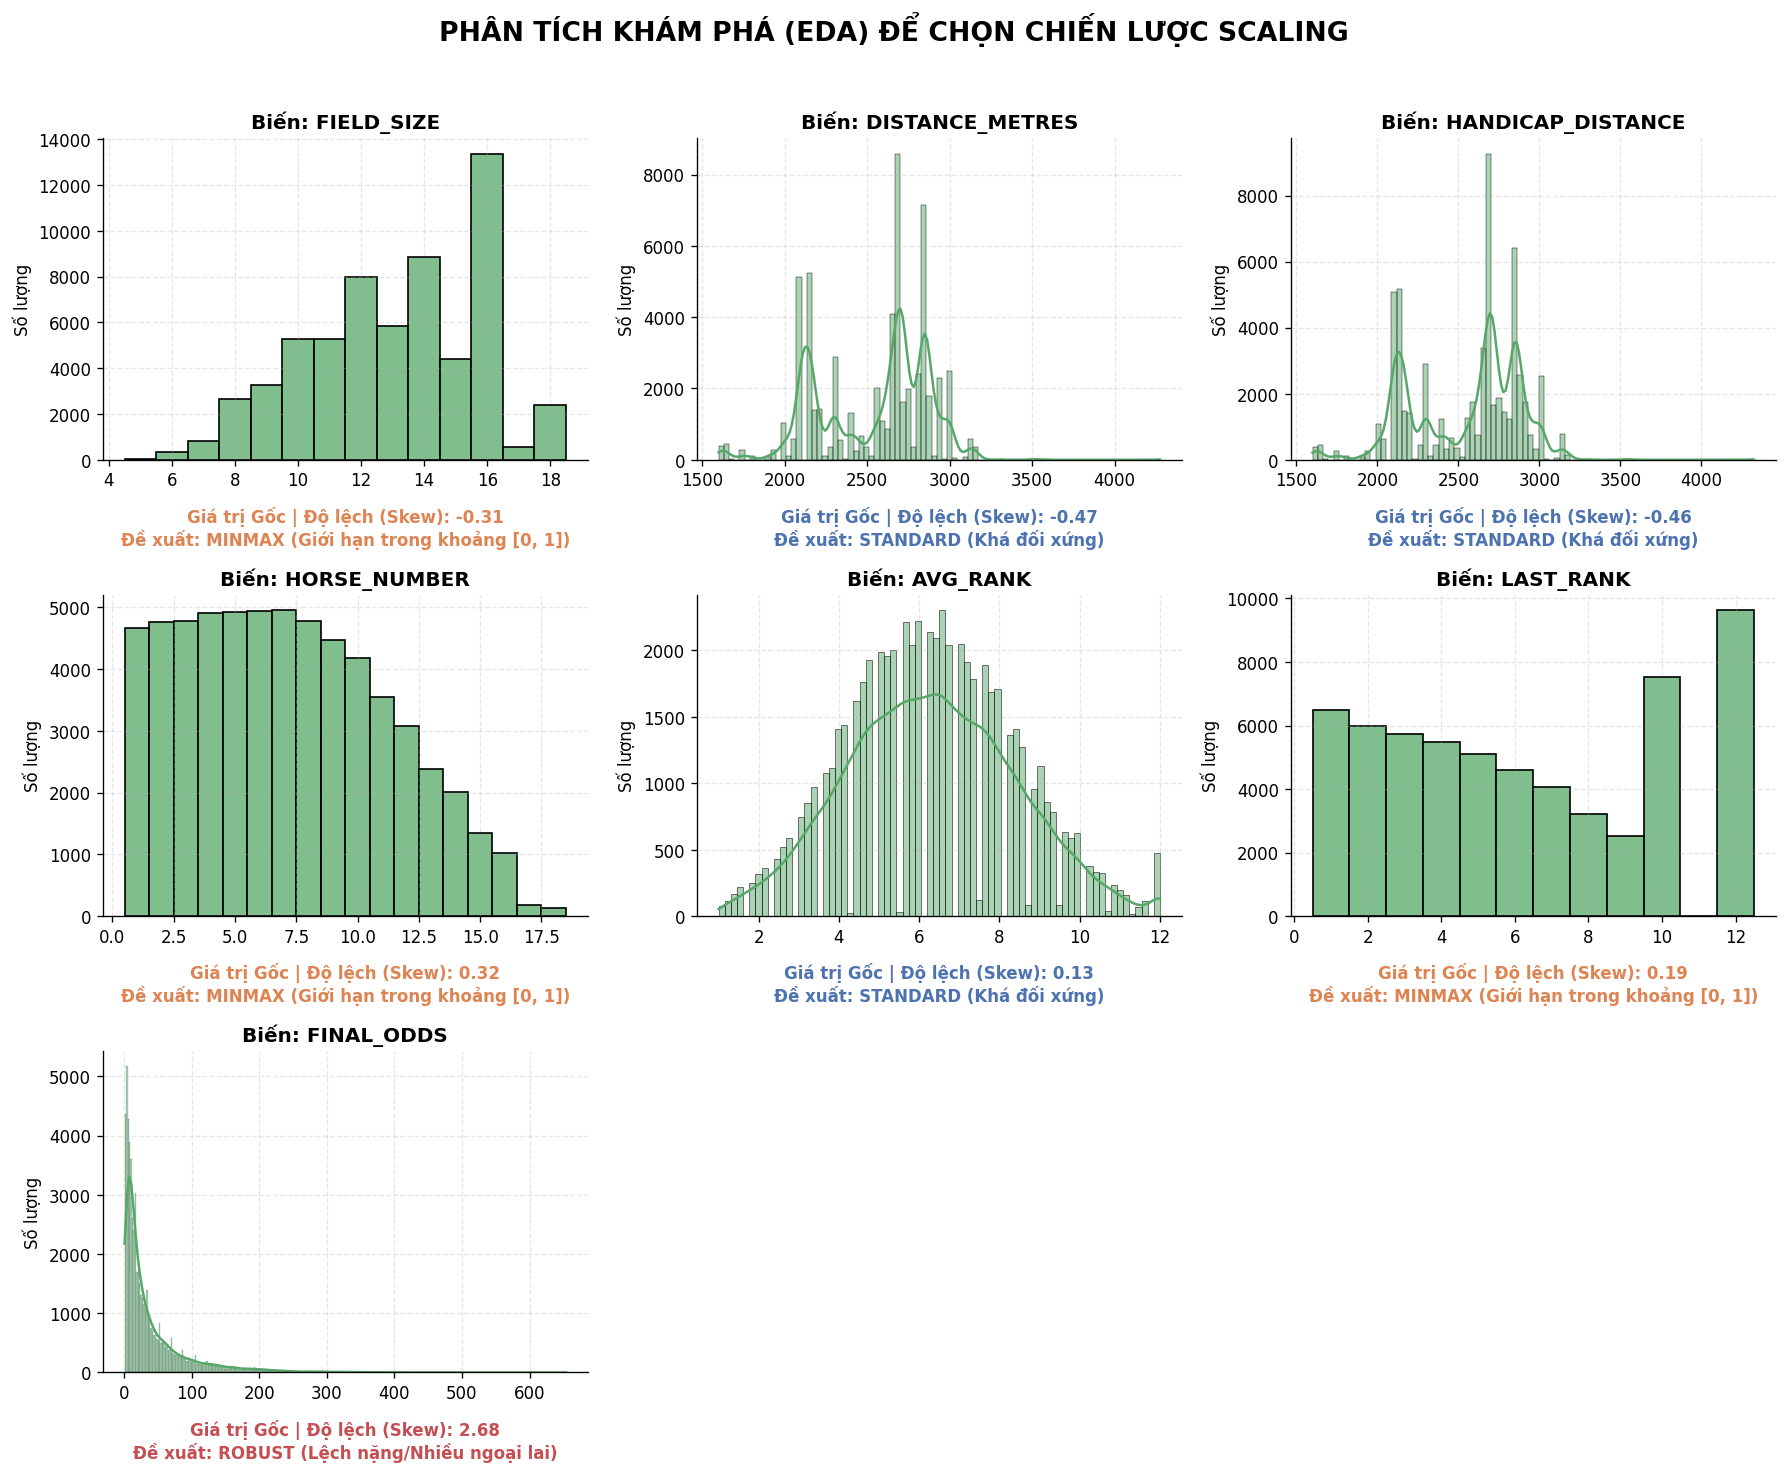

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Đang phân tích hình dáng phân phối dữ liệu gốc trên tập Train...")

# Danh sách các biến số liên tục và rời rạc cần khảo sát
features_to_check = ['field_size', 'distance_metres', 'handicap_distance', 'horse_number', 'avg_rank', 'last_rank', 'final_odds']

# Lọc ra những biến thực sự tồn tại trong df_train
available_features = [f for f in features_to_check if f in df_train.columns]
num_features = len(available_features)

if num_features == 0:
    print("Không tìm thấy biến số nào để phân tích.")
else:
    # Tính toán số hàng và cột cho lưới biểu đồ (mỗi hàng 3 biểu đồ)
    ncols = 3
    nrows = (num_features + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows), dpi=120)
    fig.suptitle('PHÂN TÍCH KHÁM PHÁ (EDA) ĐỂ CHỌN CHIẾN LƯỢC SCALING', fontsize=16, fontweight='bold', y=1.02)
    
    # Làm phẳng mảng axes để dễ lặp (tránh lỗi khi nrows=1)
    axes = axes.flatten()
    
    for i, col in enumerate(available_features):
        ax = axes[i]
        
        # Nhận diện biến rời rạc để vẽ Histogram cột thay vì đường cong liên tục
        is_discrete = True if col in ['field_size', 'horse_number', 'last_rank'] else False
        
        sns.histplot(
            data=df_train, 
            x=col, 
            kde=not is_discrete, 
            color='#55A868', 
            ax=ax,
            discrete=is_discrete
        )
        
        ax.set_title(f'Biến: {col.upper()}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Số lượng')
        ax.grid(True, linestyle='--', alpha=0.3)
        
        # Tính toán Độ lệch (Skewness) để hệ thống tự động gợi ý Scaler
        skewness = df_train[col].skew()
        
        # Logic gợi ý Scaler dựa trên độ lệch và bản chất dữ liệu
        if abs(skewness) > 1.5:
            suggestion = "Đề xuất: ROBUST (Lệch nặng/Nhiều ngoại lai)"
            color_text = '#C44E52' # Đỏ
        elif abs(skewness) <= 0.5 and not is_discrete:
             suggestion = "Đề xuất: STANDARD (Khá đối xứng)"
             color_text = '#4C72B0' # Xanh dương
        else:
            suggestion = "Đề xuất: MINMAX (Giới hạn trong khoảng [0, 1])"
            color_text = '#DD8452' # Cam
            
        ax.set_xlabel(f'Giá trị Gốc | Độ lệch (Skew): {skewness:.2f}\n{suggestion}', color=color_text, fontweight='bold', labelpad=10)

    # Xóa các khung biểu đồ trống (nếu số lượng biến không chia hết cho 3)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    sns.despine()
    plt.tight_layout()
    plt.show()

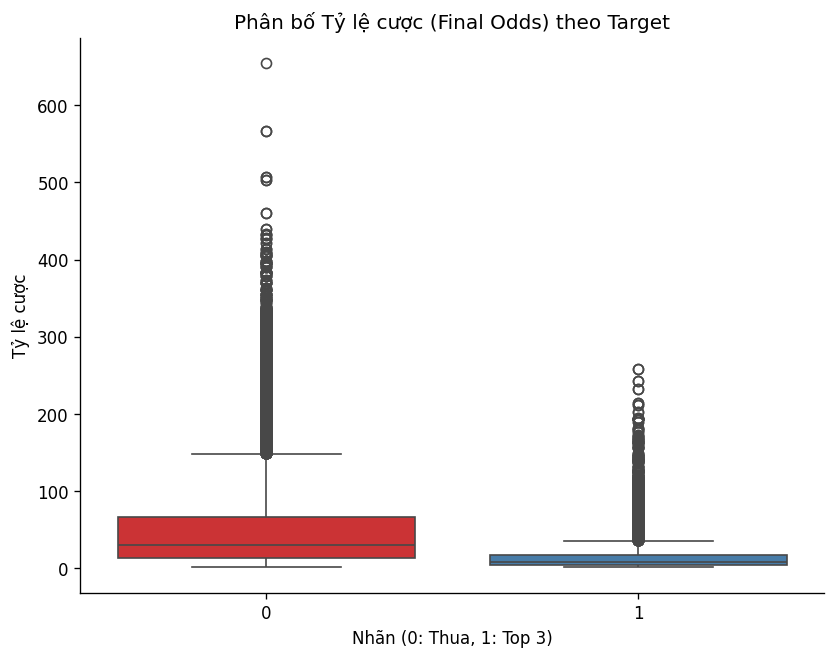

In [61]:
plt.figure(figsize=(8, 6))
# So sánh final_odds giữa 2 nhóm Target
sns.boxplot(data=df_train, x='target_top_3', y='final_odds', palette='Set1')

plt.title("Phân bố Tỷ lệ cược (Final Odds) theo Target")
plt.xlabel("Nhãn (0: Thua, 1: Top 3)")
plt.ylabel("Tỷ lệ cược")
plt.show()

In [62]:
# BƯỚC 3: Feature Engineering
# (Lưu ý: Đảm bảo rằng class FeatureEngineer đã được định nghĩa ở trên)
fe = FeatureEngineer(CONFIG)
df_train_final, df_test_final = fe.fit_transform(df_train, df_test)

# BƯỚC 5: Xem lại các tham số đã fit (debug/audit)
# print("\n--- Scalers đã fit ---")
for col, info in fe.scalers.items():
     print(f"  {col:25s} [{info['strategy']:8s}] params={info['params']}")

df_train_final

1. Đang chạy Sigmoid Target Encoding...
2. Đang chạy Multi-Strategy Normalization...
   [minmax] field_size
   [minmax] horse_number
   [standard] distance_metres
   [standard] handicap_distance
   [robust] final_odds
   [robust] avg_rank
   [robust] last_rank
  field_size                [minmax  ] params={'min': 5, 'max': 18}
  horse_number              [minmax  ] params={'min': 1, 'max': 18}
  distance_metres           [standard] params={'mean': 2546.0298568574144, 'std': 334.26308195686147}
  handicap_distance         [standard] params={'mean': 2548.845949752694, 'std': 336.5903575876663}
  final_odds                [robust  ] params={'median': 20.0, 'iqr': 41.8}
  avg_rank                  [robust  ] params={'median': 6.2, 'iqr': 3.0}
  last_rank                 [robust  ] params={'median': 6.0, 'iqr': 7.0}


,distance_metres,field_size,horse_number,handicap_distance,deferre,musique,discipline_race,field_size_race,hippodrome,final_odds,...,implied_prob_norm,target_top_3,discipline_binary,last_rank,avg_rank,win_rate,top_3_rate,jockey_name_prob,horse_name_prob,trainer_name_prob
0,-1.184785,0.153846,0.000000,-1.184960,True,6aDa6a5aRa7a,TROT_ATTELE,7,SON PARDO,0.717703,...,0.035971,0,0,0.000000,0.333333,0.000000,0.000000,0.193548,2.377793e-10,0.037037
1,-1.184785,0.153846,0.000000,-1.184960,True,6aDa6a5aRa7a,TROT_ATTELE,7,SON PARDO,0.717703,...,0.035971,0,0,0.000000,0.333333,0.000000,0.000000,0.193548,2.377793e-10,0.037037
2,-1.184785,0.153846,0.058824,-1.184960,False,3a2a4a6a0a4a,TROT_ATTELE,7,SON PARDO,-0.239234,...,0.086329,1,0,-0.428571,-0.400000,0.000000,0.285714,0.430769,2.857177e-01,0.473684
3,-1.184785,0.153846,0.058824,-1.184960,False,3a2a4a6a0a4a,TROT_ATTELE,7,SON PARDO,-0.239234,...,0.086329,1,0,-0.428571,-0.400000,0.000000,0.285714,0.430769,2.857177e-01,0.473684
4,-1.184785,0.153846,0.117647,-1.184960,False,1a1a0a6a6a2a,TROT_ATTELE,7,SON PARDO,-0.320574,...,0.196202,1,0,-0.714286,-0.466667,0.285714,0.428571,0.553571,3.000000e-01,0.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80084,-1.334368,0.846154,0.705882,-1.333508,True,(25)Da1a1a4aDa1a2a7aDa,TROT_ATTELE,16,VINCENNES,-0.394737,...,0.179759,1,0,0.857143,-0.066667,0.300000,0.400000,0.315556,8.153951e-01,0.449541
80085,-1.334368,0.846154,0.705882,-1.333508,True,(25)Da1a1a4aDa1a2a7aDa,TROT_ATTELE,16,VINCENNES,-0.394737,...,0.179759,1,0,0.857143,-0.066667,0.300000,0.400000,0.315556,8.153951e-01,0.449541
80088,-1.334368,0.846154,0.823529,-1.333508,True,6a0a(25)0a7aDmDa6a5a8a,TROT_ATTELE,16,VINCENNES,0.239234,...,0.039221,0,0,0.000000,0.933333,0.000000,0.000000,0.345361,5.237350e-06,0.169014
80089,-1.334368,0.846154,0.823529,-1.333508,True,6a0a(25)0a7aDmDa6a5a8a,TROT_ATTELE,16,VINCENNES,0.239234,...,0.039221,0,0,0.000000,0.933333,0.000000,0.000000,0.345361,5.237350e-06,0.169014


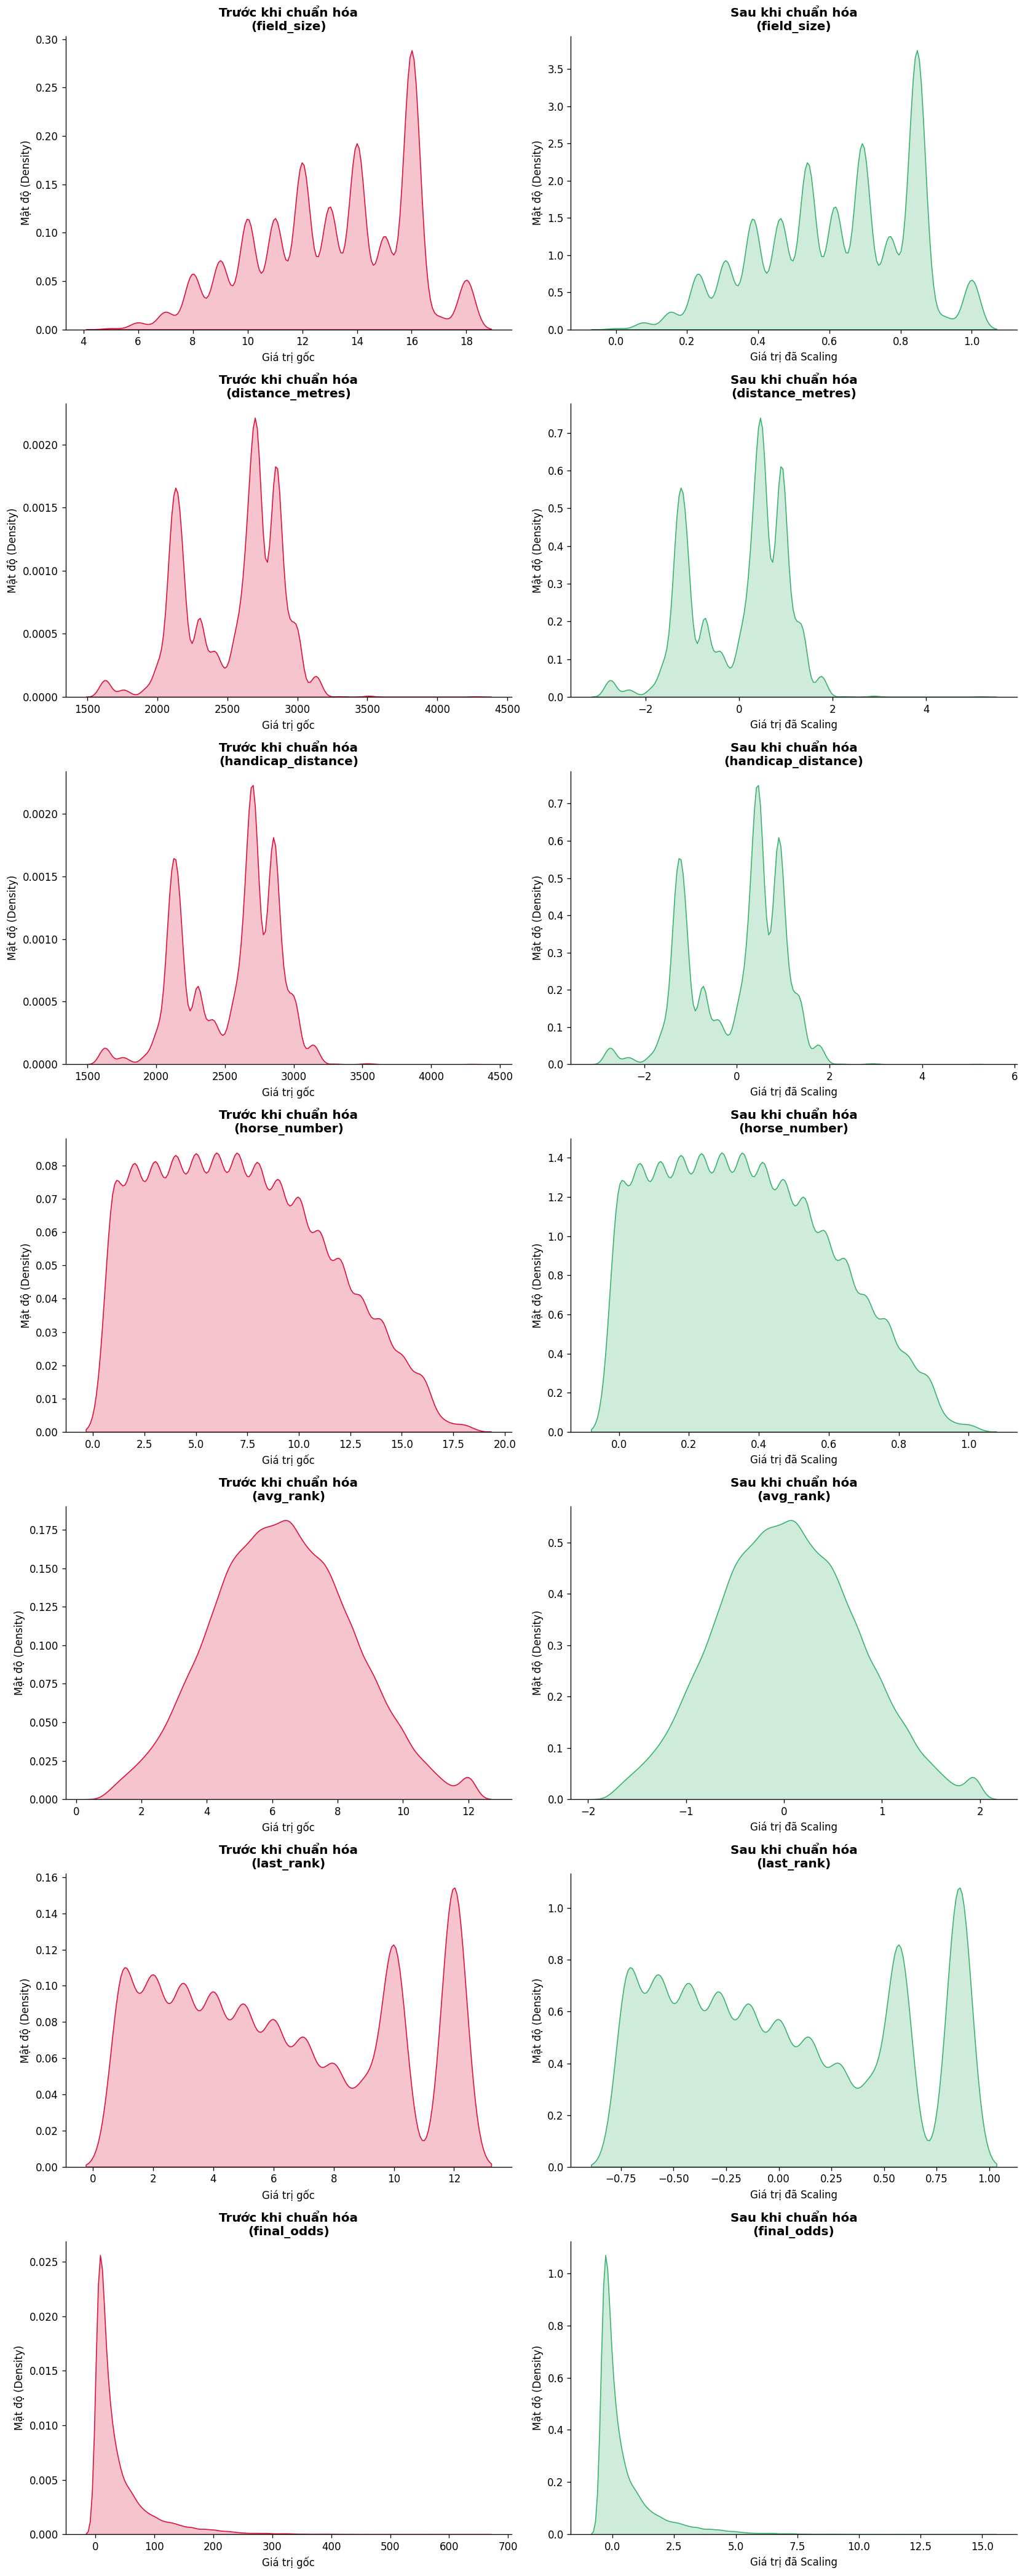

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_multiple_scaling_impact(df_original, df_scaled, features_list):
    """
    Hàm vẽ biểu đồ so sánh phân phối trước và sau khi chuẩn hóa cho nhiều biến.
    - df_original: DataFrame chứa dữ liệu gốc.
    - df_scaled: DataFrame chứa dữ liệu đã chuẩn hóa.
    - features_list: Mảng (list) chứa tên các cột cần kiểm tra.
    """
    num_features = len(features_list)
    
    # Tạo lưới biểu đồ: Số hàng = số lượng feature, Số cột = 2
    # squeeze=False đảm bảo axes luôn là mảng 2 chiều ngay cả khi chỉ có 1 feature
    fig, axes = plt.subplots(nrows=num_features, ncols=2, 
                             figsize=(14, 5 * num_features), squeeze=False)
    
    for i, feature_name in enumerate(features_list):
        # --- 1. Biểu đồ Trước khi chuẩn hóa (Cột trái) ---
        # Kiểm tra xem cột có tồn tại trong tập gốc không
        if feature_name in df_original.columns:
            sns.kdeplot(data=df_original, x=feature_name, fill=True, color='crimson', ax=axes[i, 0])
            axes[i, 0].set_title(f'Trước khi chuẩn hóa\n({feature_name})', fontsize=12, fontweight='bold')
            axes[i, 0].set_xlabel('Giá trị gốc')
            axes[i, 0].set_ylabel('Mật độ (Density)')
        else:
            axes[i, 0].text(0.5, 0.5, f"Lỗi: Không có cột '{feature_name}'", 
                            ha='center', va='center', color='red')

        # --- 2. Biểu đồ Sau khi chuẩn hóa (Cột phải) ---
        # Kiểm tra xem cột có tồn tại trong tập đã chuẩn hóa không
        if feature_name in df_scaled.columns:
            sns.kdeplot(data=df_scaled, x=feature_name, fill=True, color='mediumseagreen', ax=axes[i, 1])
            axes[i, 1].set_title(f'Sau khi chuẩn hóa\n({feature_name})', fontsize=12, fontweight='bold')
            axes[i, 1].set_xlabel('Giá trị đã Scaling')
            axes[i, 1].set_ylabel('Mật độ (Density)')
        else:
            axes[i, 1].text(0.5, 0.5, f"Lỗi: Không có cột '{feature_name}'", 
                            ha='center', va='center', color='red')
            
        # Ẩn đường viền trên và phải cho từng subplot đồ thị đẹp hơn
        sns.despine(ax=axes[i, 0])
        sns.despine(ax=axes[i, 1])
    
    # Tự động căn chỉnh khoảng cách giữa các hàng và cột để không bị đè chữ lên nhau
    plt.tight_layout()
    plt.show()

plot_multiple_scaling_impact(df_train, df_train_final, features_to_check)

## Hướng dẫn thử nghiệm strategy mới

### Thêm strategy tùy chỉnh
```python
# 1. Định nghĩa fit + transform
def my_fit(s):              return {'q05': s.quantile(0.05), 'q95': s.quantile(0.95)}
def my_transform(s, p):    return (s - p['q05']) / max(p['q95'] - p['q05'], 1e-9)

# 2. Đăng ký
ScalerRegistry.register('winsorized', my_fit, my_transform)

# 3. Dùng trong config
CONFIG['numerical_configs']['winsorized'] = ['final_odds', 'avg_rank']
```

### So sánh nhiều strategy
```python
results = {}
for strategy in ['minmax', 'standard', 'robust', 'log']:
    cfg = {**CONFIG, 'numerical_configs': {strategy: ['final_odds', 'avg_rank'], 'none': ['last_rank']}}
    fe = FeatureEngineer(cfg)
    tr, te = fe.fit_transform(df_train.copy(), df_test.copy())
    results[strategy] = tr  # rồi dùng model để đánh giá
```

In [64]:
df_train_final = df_train_final.drop("musique", axis = 1)
df_test_final = df_test_final.drop("musique", axis = 1)

In [65]:
def convert_bool_to_int(value):
    if value == True:
        return 1
    return 0
df_train_final["deferre"] = df_train_final["deferre"].apply(convert_bool_to_int)

In [66]:
df_train_final = df_train_final.drop("discipline_race", axis = 1)
df_test_final = df_test_final.drop("discipline_race", axis = 1)

In [23]:
!pip install category_encoders


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [67]:
import category_encoders as ce

# 1. Khởi tạo bộ mã hóa: hippodrome
encoder = ce.TargetEncoder(cols=['hippodrome'], smoothing=10)

# 2. Học và dịch cho tập Train
print("Đang dịch tên Trường đua...")
df_train_final = encoder.fit_transform(df_train_final, df_train_final['target_top_3'])

# 3. Dịch cho tập Test (Dựa trên trí nhớ từ bước 2)
df_test_final = encoder.transform(df_test_final)

print("Xong! Toàn bộ dữ liệu đã là số 100%. Sẵn sàng gọi AI!")

Đang dịch tên Trường đua...
Xong! Toàn bộ dữ liệu đã là số 100%. Sẵn sàng gọi AI!


In [68]:
import pandas as pd

# 2. Xóa cột rác
df_train_final = df_train_final.drop(columns=['field_size_race'], errors='ignore')
df_test_final = df_test_final.drop(columns=['field_size_race'], errors='ignore')

# 3. Kỹ thuật Trám lỗ hổng (Fill NaN)
# Trám các hạng thi đấu bằng một con số lớn (tượng trưng cho hạng bét hoặc trung bình)
df_train_final[['last_rank', 'avg_rank']] = df_train_final[['last_rank', 'avg_rank']].fillna(10.0)
df_test_final[['last_rank', 'avg_rank']] = df_test_final[['last_rank', 'avg_rank']].fillna(10.0)

# Trám tỷ lệ cược bằng giá trị Trung vị (Median) của cột đó
for col in ['final_odds', 'odds_drift_pct']:
    median_val = df_train_final[col].median()
    df_train_final[col] = df_train_final[col].fillna(median_val)
    df_test_final[col] = df_test_final[col].fillna(median_val)

print("Đã làm sạch dữ liệu!")

Đã làm sạch dữ liệu!


In [69]:
df_train_final

,distance_metres,field_size,horse_number,handicap_distance,deferre,hippodrome,final_odds,odds_drift_pct,implied_prob_norm,target_top_3,discipline_binary,last_rank,avg_rank,win_rate,top_3_rate,jockey_name_prob,horse_name_prob,trainer_name_prob
0,-1.184785,0.153846,0.000000,-1.184960,1,0.346512,0.717703,1.0833,0.035971,0,0,0.000000,0.333333,0.000000,0.000000,0.193548,2.377793e-10,0.037037
1,-1.184785,0.153846,0.000000,-1.184960,1,0.346512,0.717703,1.0833,0.035971,0,0,0.000000,0.333333,0.000000,0.000000,0.193548,2.377793e-10,0.037037
2,-1.184785,0.153846,0.058824,-1.184960,0,0.346512,-0.239234,0.0000,0.086329,1,0,-0.428571,-0.400000,0.000000,0.285714,0.430769,2.857177e-01,0.473684
3,-1.184785,0.153846,0.058824,-1.184960,0,0.346512,-0.239234,0.0000,0.086329,1,0,-0.428571,-0.400000,0.000000,0.285714,0.430769,2.857177e-01,0.473684
4,-1.184785,0.153846,0.117647,-1.184960,0,0.346512,-0.320574,0.5000,0.196202,1,0,-0.714286,-0.466667,0.285714,0.428571,0.553571,3.000000e-01,0.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80084,-1.334368,0.846154,0.705882,-1.333508,1,0.301715,-0.394737,-0.2708,0.179759,1,0,0.857143,-0.066667,0.300000,0.400000,0.315556,8.153951e-01,0.449541
80085,-1.334368,0.846154,0.705882,-1.333508,1,0.301715,-0.394737,-0.2708,0.179759,1,0,0.857143,-0.066667,0.300000,0.400000,0.315556,8.153951e-01,0.449541
80088,-1.334368,0.846154,0.823529,-1.333508,1,0.301715,0.239234,0.3636,0.039221,0,0,0.000000,0.933333,0.000000,0.000000,0.345361,5.237350e-06,0.169014
80089,-1.334368,0.846154,0.823529,-1.333508,1,0.301715,0.239234,0.3636,0.039221,0,0,0.000000,0.933333,0.000000,0.000000,0.345361,5.237350e-06,0.169014


In [70]:
Y_train = df_train_final["target_top_3"]
X_train = df_train_final.drop("target_top_3", axis = 1)
Y_test = df_test_final["target_top_3"]
X_test = df_test_final.drop("target_top_3", axis = 1)

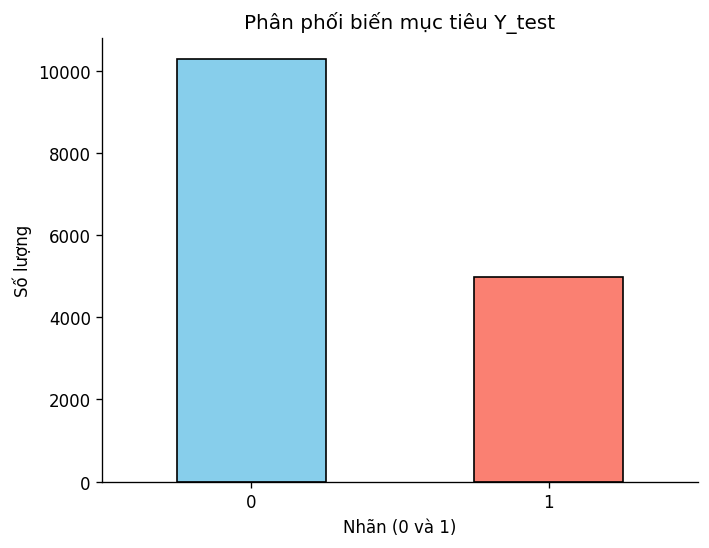

In [71]:
# Đếm số lượng mỗi nhãn và vẽ biểu đồ cột
Y_test.value_counts().plot(kind='bar', color=['skyblue', 'salmon'], edgecolor='black')

import matplotlib.pyplot as plt
plt.title("Phân phối biến mục tiêu Y_test")
plt.xlabel("Nhãn (0 và 1)")
plt.ylabel("Số lượng")
plt.xticks(rotation=0)
plt.show()

In [24]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# 1. Định nghĩa mô hình cơ bản
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# 2. Đưa ra các lựa chọn tham số muốn máy tự thử
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.5],
    'max_depth': [3, 5, 7, 9, 11]
}

# 3. Chạy hàm tìm kiếm
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, Y_train)

# 4. In ra bộ tham số tối ưu nhất máy tìm được
print("Tham số tốt nhất:", grid_search.best_params_)

Tham số tốt nhất: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 400}


In [72]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import classification_report, precision_score

print("Đang huấn luyện XGBoost... (Sẽ mất khoảng 10-30 giây)")
xgb_model = xgb.XGBClassifier(
    n_estimators=400,        # Xây dựng 400 cây quyết định
    learning_rate=0.05,      # Tốc độ học (chậm mà chắc để không bỏ sót quy luật)
    max_depth=3,             # Độ sâu của cây (Giữ mức 5 để tránh học vẹt/overfitting)
    random_state=42,
    n_jobs=-1,               # Vắt kiệt sức mạnh CPU để chạy nhanh nhất
    eval_metric='logloss'    # Thước đo tiêu chuẩn để máy tự chấm điểm lúc học
)
xgb_model.fit(X_train, Y_train)

# BƯỚC 3: DỰ ĐOÁN XÁC SUẤT (%)
# ==========================================
# Không dùng lệnh predict() cứng nhắc, ta lấy XÁC SUẤT lọt Top 3 của từng con ngựa
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# BƯỚC 4: CHIẾN THUẬT TEST DÒNG TIỀN (THRESHOLD TUNING)
# ==========================================
# Ta sẽ thử bắt AI làm việc với 4 mức độ khó tính khác nhau
nguong_thu_nghiem = [0.80, 0.85, 0.90, 0.95]

print("--- PHÂN TÍCH TỶ LỆ TRÚNG THEO ĐỘ KHÓ TÍNH CỦA AI ---")
for nguong in nguong_thu_nghiem:
    # Nếu xác suất > ngưỡng, mới gán nhãn 1 (đặt cược)
    y_pred_custom = (y_probs >= nguong).astype(int)
    
    so_tran_danh = sum(y_pred_custom)
    
    # Nếu AI quá khắt khe, không tìm được con nào thì bỏ qua
    if so_tran_danh == 0:
        print(f"Ngưỡng {nguong*100}%: AI chê tất cả! Không phím con nào.")
        continue
        
    # Chấm điểm Precision cho tập ngựa vừa phím
    precision = precision_score(Y_test, y_pred_custom, pos_label=1)
    
    print(f"Khi AI tự tin trên {nguong*100}%: ")
    print(f"Số ngựa AI khuyên đánh: {so_tran_danh} con (trên tổng số {len(Y_test)} ngựa thi đấu)")
    print(f"Tổng ngựa: {so_tran_danh / len(Y_test) * 100:.2f}%")
    print(f"Tỷ lệ đoán trúng (Precision): {precision * 100:.2f}%")
    print("-" * 50)

Đang huấn luyện XGBoost... (Sẽ mất khoảng 10-30 giây)
--- PHÂN TÍCH TỶ LỆ TRÚNG THEO ĐỘ KHÓ TÍNH CỦA AI ---
Khi AI tự tin trên 80.0%: 
Số ngựa AI khuyên đánh: 1821 con (trên tổng số 15265 ngựa thi đấu)
Tổng ngựa: 11.93%
Tỷ lệ đoán trúng (Precision): 62.60%
--------------------------------------------------
Khi AI tự tin trên 85.0%: 
Số ngựa AI khuyên đánh: 1466 con (trên tổng số 15265 ngựa thi đấu)
Tổng ngựa: 9.60%
Tỷ lệ đoán trúng (Precision): 63.17%
--------------------------------------------------
Khi AI tự tin trên 90.0%: 
Số ngựa AI khuyên đánh: 1080 con (trên tổng số 15265 ngựa thi đấu)
Tổng ngựa: 7.08%
Tỷ lệ đoán trúng (Precision): 67.69%
--------------------------------------------------
Khi AI tự tin trên 95.0%: 
Số ngựa AI khuyên đánh: 633 con (trên tổng số 15265 ngựa thi đấu)
Tổng ngựa: 4.15%
Tỷ lệ đoán trúng (Precision): 72.04%
--------------------------------------------------
